# VAE

In [1]:
# Import required packages
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models
import numpy as np
from tqdm import tqdm
from dataset_utils import get_data_loaders

## Hyperparams

In [ ]:
dataset = "cifar100"
batch_size = 256
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
latent_dim = 128
lr = 2e-4
weight_decay = 2e-5
num_epochs = 300
kl_weight = 0


In [3]:
print(dataset, latent_dim, kl_weight)

cifar100 128 0


## VAE Structure

In [4]:
class ConvVAE(nn.Module):
    def __init__(self, img_size=32, channel_num = 3, kernel_num = 128, layers_num = 3, latent_dim=256):
        super().__init__()
        self.img_size = img_size
        self.channel_num = channel_num
        self.kernel_num = kernel_num
        self.depth = layers_num
        self.latent_dim = latent_dim

        # ---------- Encoder ----------
        self.enc = nn.Sequential(
            self._conv(channel_num, kernel_num // (2 ** (layers_num - 1))),
            *[self._conv(kernel_num // (2 ** k), kernel_num // (2 ** (k - 1))) for k in range(layers_num - 1, 0, -1)],
        )

        self.feat_size = img_size // (2 ** layers_num)
        self.feat_dim = self.feat_size * self.feat_size * self.kernel_num

        self.mu = nn.Linear(self.feat_dim, latent_dim)
        self.logvar = nn.Linear(self.feat_dim, latent_dim)

        # ---------- Decoder ----------
        self.fc_dec = nn.Linear(latent_dim, self.feat_dim)

        self.dec = nn.Sequential(
            *[self._deconv(kernel_num // (2 ** k), kernel_num // (2 ** (k+1))) for k in range(layers_num - 1)],
            nn.ConvTranspose2d(kernel_num // (2 ** (layers_num - 1)), channel_num, 4, 2, 1),
        )

    def encode(self, x):
        h = self.enc(x)
        h = h.view(h.size(0), -1)
        mu = self.mu(h)
        logvar = self.logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = (0.5 * logvar).exp()
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = self.fc_dec(z)
        h = h.view(-1, self.kernel_num, self.feat_size, self.feat_size)
        return self.dec(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_rec = self.decode(z)
        return x_rec, mu, logvar, z

    # Layers
    def _conv(self, channel_num, kernel_num):
        return nn.Sequential(
            nn.Conv2d(channel_num, kernel_num, 4, 2, 1), 
            nn.GroupNorm(num_groups=32, num_channels=kernel_num),
            nn.ReLU(),
        )
    
    def _deconv(self, channel_num, kernel_num):
        return nn.Sequential(
            nn.ConvTranspose2d(channel_num, kernel_num, 4, 2, 1), 
            nn.GroupNorm(num_groups=32, num_channels=kernel_num),
            nn.ReLU(),
        )

In [5]:
def reconstruction_loss(x, x_hat):
    return F.mse_loss(x_hat, x, reduction="sum") 

def kl_divergence(mu, logvar):
    return -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) 

def vae_loss(x, x_hat, mu, logvar, beta=1.0):
    recon_loss = reconstruction_loss(x, x_hat) / x.size(0)
    kld = kl_divergence(mu, logvar) / x.size(0)

    total_loss = recon_loss + beta * kld
    return total_loss, recon_loss, kld    

### Define optimizer and start training.

In [6]:
def beta_schedule(epoch, beta, warmup_epochs):
    return beta * min(1.0, epoch / warmup_epochs)


In [7]:
model = ConvVAE(img_size=32, latent_dim=latent_dim, layers_num=3).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

train_loader, test_loader = get_data_loaders(dataset=dataset)
class_names = train_loader.dataset.classes
labels = [f"{i}_{name}" for i, name in enumerate(class_names)]
print(labels)
for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    total_recon = 0
    total_kld = 0

    for x, y in tqdm(train_loader, leave=False):
        x = x.to(device)

        x_hat, mu, logvar, z = model(x)

        loss, recon, kld = vae_loss(x, x_hat, mu, logvar, beta=beta_schedule(epoch+1, kl_weight, 60))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_recon += recon.item()
        total_kld += kld.item()

    print(f"Epoch {epoch+1}/{num_epochs} "
          f"Loss={total_loss/len(train_loader):.4f} "
          f"Recon={total_recon/len(train_loader):.4f} "
          f"KLD={total_kld/len(train_loader):.4f}")


100%|██████████| 169M/169M [00:13<00:00, 12.8MB/s] 


['0_apple', '1_aquarium_fish', '2_baby', '3_bear', '4_beaver', '5_bed', '6_bee', '7_beetle', '8_bicycle', '9_bottle', '10_bowl', '11_boy', '12_bridge', '13_bus', '14_butterfly', '15_camel', '16_can', '17_castle', '18_caterpillar', '19_cattle', '20_chair', '21_chimpanzee', '22_clock', '23_cloud', '24_cockroach', '25_couch', '26_crab', '27_crocodile', '28_cup', '29_dinosaur', '30_dolphin', '31_elephant', '32_flatfish', '33_forest', '34_fox', '35_girl', '36_hamster', '37_house', '38_kangaroo', '39_keyboard', '40_lamp', '41_lawn_mower', '42_leopard', '43_lion', '44_lizard', '45_lobster', '46_man', '47_maple_tree', '48_motorcycle', '49_mountain', '50_mouse', '51_mushroom', '52_oak_tree', '53_orange', '54_orchid', '55_otter', '56_palm_tree', '57_pear', '58_pickup_truck', '59_pine_tree', '60_plain', '61_plate', '62_poppy', '63_porcupine', '64_possum', '65_rabbit', '66_raccoon', '67_ray', '68_road', '69_rocket', '70_rose', '71_sea', '72_seal', '73_shark', '74_shrew', '75_skunk', '76_skyscraper

Epoch 1/300 Loss=3318.7271 Recon=3318.7271 KLD=479.2856


Epoch 2/300 Loss=1503.2766 Recon=1503.2766 KLD=665.4928


Epoch 3/300 Loss=1197.5385 Recon=1197.5385 KLD=735.5354


...

Epoch 296/300 Loss=332.7529 Recon=332.7529 KLD=1213.8585


Epoch 297/300 Loss=332.0388 Recon=332.0388 KLD=1212.8929


Epoch 298/300 Loss=331.9905 Recon=331.9905 KLD=1211.4378


Epoch 299/300 Loss=332.3957 Recon=332.3957 KLD=1215.5832


Epoch 300/300 Loss=332.0250 Recon=332.0250 KLD=1211.3847


In [8]:
import random
import torch

def encode_images(x):
    model.eval()
    with torch.no_grad():
        mu, _ = model.encode(x.to(device))
    return mu 

def latent_distance(x1, x2):
    return torch.norm(x1 - x2, dim=-1)


In [9]:
import torch
from collections import defaultdict

# ------------------------
# assumes:
# vae = ConvVAE(...)
# loader = CIFAR100 dataloader
# device = "cuda" or "cpu"
# ------------------------

num_classes = 10
vae = model
vae = vae.to(device)
vae.eval()


# --------------------------------------------------
# 1) Collect μ (latent mean) grouped by class label
# --------------------------------------------------
def collect_latents_by_class(vae, loader, device):
    latents_by_class = defaultdict(list)

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)

            # forward pass encoder only
            mu, logvar = vae.encode(x)     # shapes: [B, latent_dim]

            mu = mu.detach().cpu()

            for zi, yi in zip(mu, y):
                latents_by_class[int(yi.item())].append(zi)

    # convert lists to tensors
    for k in latents_by_class:
        latents_by_class[k] = torch.stack(latents_by_class[k])  # [Nk, d]

    return latents_by_class


# --------------------------------------------------
# 2) Centroid–centroid distance matrix
# --------------------------------------------------
def centroid_distance_matrix(latents_by_class, latent_distance):
    C = len(latents_by_class)

    # compute centroids
    centroids = []
    for c in range(C):
        centroids.append(latents_by_class[c].mean(dim=0))
    centroids = torch.stack(centroids)  # [C, d]

    # fill matrix
    mat = torch.zeros((C, C))
    for i in range(C):
        for j in range(C):
            mat[i, j] = latent_distance(centroids[i], centroids[j])

    return mat


# --------------------------------------------------
# 3) True average pairwise class–class distance matrix
# --------------------------------------------------
def avg_l2_between_sets(A, B):
    # A: [N, d], B: [M, d]

    AA = (A * A).sum(dim=1).unsqueeze(1)   # [N,1]
    BB = (B * B).sum(dim=1).unsqueeze(0)   # [1,M]

    AB = A @ B.T                           # [N,M]

    dist_sq = AA + BB - 2 * AB             # [N,M]

    dist = torch.sqrt(torch.clamp(dist_sq, min=1e-8))

    return dist.mean()

def pairwise_average_distance_matrix_l2(latents_by_class):
    C = len(latents_by_class)
    mat = torch.zeros((C, C))

    for i in range(C):
        zi = latents_by_class[i]

        for j in range(i, C):
            zj = latents_by_class[j]

            val = avg_l2_between_sets(zi, zj)

            mat[i, j] = val
            mat[j, i] = val

    return mat


def pairwise_average_distance_matrix(latents_by_class, latent_distance):
    C = len(latents_by_class)
    mat = torch.zeros((C, C))

    for i in range(C):
        zi = latents_by_class[i]      # [Ni, d]

        for j in range(i, C):         # notice: j starts at i
            zj = latents_by_class[j]  # [Nj, d]

            zi_exp = zi.unsqueeze(1)  # [Ni, 1, d]
            zj_exp = zj.unsqueeze(0)  # [1, Nj, d]

            dists = latent_distance(zi_exp, zj_exp)

            val = dists.mean()

            mat[i, j] = val
            mat[j, i] = val           # mirror to bottom-left

    return mat


In [10]:
latents_by_class = collect_latents_by_class(vae, train_loader, device)
centroid_matrix = centroid_distance_matrix(latents_by_class, latent_distance)
pairwise_matrix = pairwise_average_distance_matrix_l2(latents_by_class)


In [ ]:
import pandas as pd

class_names = train_loader.dataset.classes
labels = [f"{i}_{name}" for i, name in enumerate(class_names)]

def matrix_to_df(matrix, labels):
    """
    matrix: torch tensor [100,100]
    labels: list length 100
    """
    if isinstance(matrix, torch.Tensor):
        matrix = matrix.cpu().numpy()

    df = pd.DataFrame(matrix, index=labels, columns=labels)
    return df


centroid_df = matrix_to_df(centroid_matrix, labels)
pairwise_df = matrix_to_df(pairwise_matrix, labels)

output_path = f"scores/{str(kl_weight).replace('.','')}_{dataset}_latent_distances.xlsx"

with pd.ExcelWriter(output_path, engine="openpyxl") as writer:
    centroid_df.to_excel(writer, sheet_name="centroid_distance")
    pairwise_df.to_excel(writer, sheet_name="pairwise_distance")

print(f"Saved Excel file to: {output_path}")


Saved Excel file to: 0_cifar100_latent_distances.xlsx


Generating images from VAE...


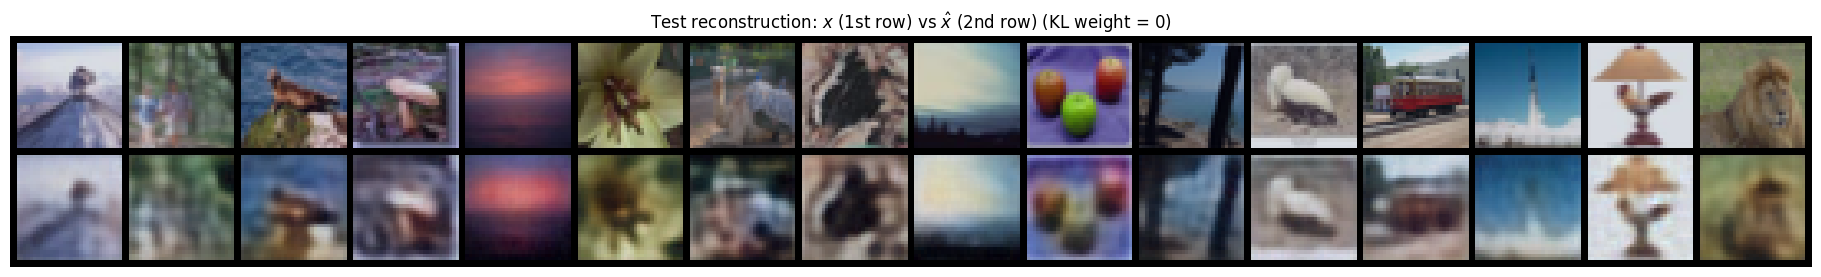

Total test reconstruction loss: 5404222.255859375


In [13]:
from torchvision.utils import save_image, make_grid
import matplotlib.pyplot as plt

def show_recon_comparison(x, x_hat, num_samples=8):
    """
    Display original vs reconstructed images side by side horizontally.

    Args:
        x: Original images tensor (batch_size, 1, 28, 28)
        x_hat: Reconstructed images tensor (batch_size, 1, 28, 28)
        num_samples: Number of image pairs to display
    """
    x_display = x[:num_samples]
    x_hat_display = x_hat[:num_samples]

    # Create comparison: first row original, second row reconstructed
    comparison = torch.cat([x_display, x_hat_display], dim=0)

    grid = make_grid(comparison, nrow=num_samples, normalize=True, padding=2)
    plt.figure(figsize=(num_samples * 1.5, 3))
    plt.imshow(grid.permute(1, 2, 0).cpu().numpy(), cmap='gray')
    plt.axis('off')
    plt.title(r'Test reconstruction: $x$ (1st row) vs $\hat{x}$ (2nd row)' + f' (KL weight = {kl_weight})')
    plt.show()

if True:
    train_loader, test_loader = get_data_loaders(dataset=dataset)
    # Evaluate Convolutional VAE and generate images
    model.eval()

    print("Generating images from VAE...")
    total_test_recon_loss = 0

    # Test reconstruction
    with torch.no_grad():
        for batch_idx, (x, _) in enumerate(test_loader):
            x = x.to(device)
            x_hat, _, _, _ = model(x)
            if batch_idx == 0:
                show_recon_comparison(x, x_hat, num_samples=16)
            recon_loss = reconstruction_loss(x, x_hat)
            total_test_recon_loss += recon_loss.item()

    print(f"Total test reconstruction loss: {total_test_recon_loss}")

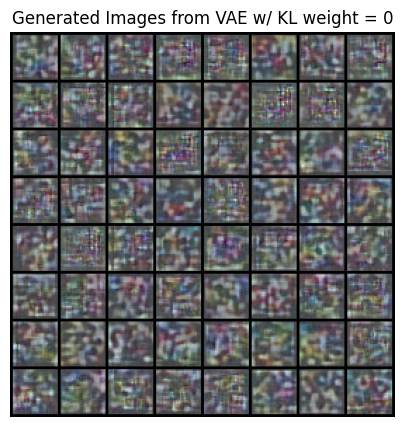

In [14]:
def sample_prior(n_samples=1):
        """
        Sample from the prior distribution.
        """
        z = torch.randn(n_samples, latent_dim).to(device=device)
        return z

if True:
    model.eval()

    # Generate new images by sampling from prior
    with torch.no_grad():
        num_samples = 64
        z = sample_prior(n_samples=num_samples)
        generated_images = model.decode(z)

        # Display in
        grid = make_grid(generated_images, nrow=8, normalize=True, padding=2)
        plt.figure(figsize=(5, 5))
        plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
        plt.axis('off')
        plt.title(f'Generated Images from VAE w/ KL weight = {kl_weight}')
        plt.show()
